In [2]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from data_store import get_df
from config import config

In [3]:
def plot_learning_curves(csv_or_df, methods=None, title=None, smooth=0):
    df = pd.read_csv(csv_or_df) if isinstance(csv_or_df, (str, os.PathLike)) else csv_or_df.copy()
    if methods: df = df[df['method'].isin(methods)]
    df = df.sort_values(['method','round'])
    ycol = 'accuracy'
    if smooth and smooth > 1:
        df['acc_smooth'] = df.groupby('method')['accuracy'].transform(lambda s: s.rolling(smooth, 1).mean())
        ycol = 'acc_smooth'

    y0 = df.groupby('method').apply(lambda g: g.sort_values('round')[ycol].iloc[0]).min()
    y1 = min(1.0, df[ycol].max() + 0.01)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

    for m, g in df.groupby('method'):
        axes[0].plot(g['round'], g[ycol], marker='o', linewidth=2, markersize=3, label=m)
    axes[0].set_xlabel('round'); axes[0].set_ylabel('accuracy')
    axes[0].set_ylim(max(0.0, y0 - 0.02), y1)
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].yaxis.set_major_locator(MaxNLocator(6))
    axes[0].grid(True, which='both', linestyle='--', alpha=0.35)

    if 'labels' in df.columns:
        for m, g in df.groupby('method'):
            axes[1].plot(g['labels'], g[ycol], marker='o', linewidth=2, markersize=3, label=m)
        axes[1].set_xlabel('labeled count')
        axes[1].set_ylim(max(0.0, y0 - 0.02), y1)
        axes[1].yaxis.set_major_locator(MaxNLocator(6))
        axes[1].grid(True, which='both', linestyle='--', alpha=0.35)

    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    axes[0].legend(loc='lower right', frameon=True)
    axes[1].legend(loc='lower right', frameon=True)
    if title: fig.suptitle(title)
    plt.show()
    return fig, axes

In [8]:
def plot_acc_pct(csv_or_df, methods=None, title=None,
                 y_min=0.0, y_max=1.0, use_top_k=True,
                 band='std', x_range=None, test_size=config.get('test_size')):
    df = pd.read_csv(csv_or_df) if isinstance(csv_or_df, (str, os.PathLike)) else csv_or_df.copy()
    if methods is not None:
        if isinstance(methods, str): methods = [methods]
        df = df[df['method'].isin(methods)].copy()

    tuple_col = 'acc_tuple_topk' if use_top_k else 'acc_tuple_top1'
    avg_col   = 'avg_acc_topk'   if use_top_k else 'avg_acc_top1'
    if tuple_col not in df.columns:
        if 'acc_tuple' in df.columns:
            tuple_col = 'acc_tuple'
        elif avg_col in df.columns:
            df[tuple_col] = df[avg_col].apply(lambda x: json.dumps([float(x)]))
        elif 'avg_acc' in df.columns:
            df[tuple_col] = df['avg_acc'].apply(lambda x: json.dumps([float(x)]))
        else:
            raise ValueError(f"Missing accuracy columns. Tried: {[tuple_col, avg_col, 'acc_tuple', 'avg_acc']}")

    if 'pct_before' in df.columns:
        df['pct'] = df['pct_before'].astype(float)
    elif 'pct' in df.columns:
        df['pct'] = df['pct'].astype(float)
    elif {'labels_before', 'pool_size'}.issubset(df.columns):
        df['pct'] = 100.0 * df['labels_before'].astype(float) / df['pool_size'].astype(float)
    elif {'labels', 'pool_size'}.issubset(df.columns):
        df['pct'] = 100.0 * df['labels'].astype(float) / df['pool_size'].astype(float)
    else:
        raise ValueError("Need either 'pct' or ('labels'|'labels_before' and 'pool_size').")

    def _parse_tuple(x):
        if isinstance(x, (list, tuple)): return tuple(float(v) for v in x)
        if pd.isna(x): return tuple()
        try: return tuple(float(v) for v in json.loads(x))
        except Exception:
            s = str(x).strip().strip('()[]')
            parts = [p for p in s.split(',') if p.strip()]
            return tuple(float(p) for p in parts)

    df['acc_tuple_use'] = df[tuple_col].apply(_parse_tuple)

    if test_size is None and 'test_size' not in df.columns:
        df['x_pct'] = df['pct'].astype(float)
        x_label = '% of training pool classified'
    else:
        if test_size is not None:
            if isinstance(test_size, str):
                try: test_size = float(test_size)
                except: pass
            if isinstance(test_size, (float, np.floating)) and 0.0 <= float(test_size) <= 1.0:
                df['x_pct'] = df['pct'] * (1.0 - float(test_size))
                x_label = '% of dataset classified'
            elif isinstance(test_size, (int, np.integer)) and int(test_size) >= 1:
                if 'pool_size' not in df.columns:
                    raise ValueError("Absolute test_size requires 'pool_size' in df.")
                denom = df['pool_size'].astype(float) + float(test_size)
                df['x_pct'] = (df['pct'] * df['pool_size'].astype(float)) / denom
                x_label = '% of dataset classified'
            else:
                df['x_pct'] = df['pct']
                x_label = '% of dataset classified'
        else:
            ts = df['test_size']
            ts_num = pd.to_numeric(ts, errors='coerce')
            is_frac = ts_num.between(0.0, 1.0, inclusive='both')
            if 'pool_size' in df.columns:
                denom = df['pool_size'].astype(float) + ts_num.where(~is_frac, np.nan)
            else:
                denom = np.nan
            df['x_pct'] = np.where(is_frac, df['pct'] * (1.0 - ts_num),
                                   (df['pct'] * df['pool_size'].astype(float)) / denom)
            df['x_pct'] = pd.to_numeric(df['x_pct'], errors='coerce').fillna(df['pct'])
            x_label = '% of dataset classified'

    df_long = df.explode('acc_tuple_use', ignore_index=True).rename(columns={'acc_tuple_use': 'acc'})
    df_long['acc'] = pd.to_numeric(df_long['acc'], errors='coerce')
    df_long = df_long.dropna(subset=['acc'])
    if df_long.empty:
        raise ValueError("No accuracy data to plot.")

    summary = (
        df_long.groupby(['method', 'round'], as_index=False)
               .agg(mean_acc=('acc', 'mean'),
                    std_acc=('acc', 'std'),
                    n=('acc', 'count'),
                    x_pct=('x_pct', 'first'))
               .sort_values(['method', 'x_pct'])
    )
    summary['std_acc'] = summary['std_acc'].fillna(0.0)
    if band not in ('std', 'sem'):
        band = 'std'
    summary['band'] = summary['std_acc'] if band == 'std' else summary['std_acc'] / np.sqrt(summary['n'].clip(lower=1))
    summary['mean_acc_pct'] = summary['mean_acc'] * 100.0
    summary['band_pct'] = summary['band'] * 100.0

    if x_range and len(x_range) == 2:
        lo, hi = x_range
        if hi <= 1.0:
            lo, hi = lo * 100.0, hi * 100.0
        summary = summary[(summary['x_pct'] >= lo) & (summary['x_pct'] <= hi)]

    if summary.empty:
        lo_all, hi_all = float(df['x_pct'].min()), float(df['x_pct'].max())
        raise ValueError(f"No data left after applying x_range={x_range}. Available x range: {lo_all:.2f}–{hi_all:.2f}")

    methods_used = list(pd.unique(summary['method']))
    passive = [m for m in methods_used if m.startswith('passive_')]
    active  = [m for m in methods_used if m.startswith('active_')]
    other   = [m for m in methods_used if m not in passive + active]
    pal = {}
    if passive:
        c = sns.color_palette('Blues', max(3, len(passive)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(passive)})
    if active:
        c = sns.color_palette('Oranges', max(3, len(active)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(active)})
    if other:
        c = sns.color_palette('Greys', max(3, len(other)+1))[1:]
        pal.update({m: c[i] for i, m in enumerate(other)})

    sns.set_theme(style="whitegrid", context="notebook", font_scale=0.9)
    fig, ax = plt.subplots(figsize=(10, 8))

    sns.lineplot(
        data=summary, x='x_pct', y='mean_acc_pct', hue='method',
        estimator=None, marker='o', linewidth=2.5, markersize=2.5,
        palette=pal, ax=ax
    )

    for m, g in summary.groupby('method'):
        x = g['x_pct'].to_numpy()
        y = g['mean_acc_pct'].to_numpy()
        b = g['band_pct'].to_numpy()
        if len(x) >= 2:
            lower = np.clip(y - b, 0.0, 100.0)
            upper = np.clip(y + b, 0.0, 100.0)
            ax.fill_between(x, lower, upper, color=pal[m], alpha=0.15, linewidth=0)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Accuracy in %', fontsize=11)

    y_min_pct = float(y_min * 100.0) if y_max <= 1.0 and y_min <= 1.0 else float(y_min)
    y_max_pct = float(y_max * 100.0) if y_max <= 1.0 and y_min <= 1.0 else float(y_max)
    y_min_pct = max(0.0, y_min_pct)
    y_max_pct = min(100.0, y_max_pct)

    if x_range and len(x_range) == 2:
        lo, hi = x_range
        if hi <= 1.0:
            lo, hi = lo * 100.0, hi * 100.0
        ax.set_xlim(lo, hi)
    else:
        ax.set_xlim(float(summary['x_pct'].min()), float(summary['x_pct'].max()))

    ax.set_ylim(y_min_pct, y_max_pct)
    ax.set_yticks(np.arange(y_min_pct, y_max_pct + 0.001, 5.0))

    metric_label = f"Top-{int(df['top_k'].mode()[0])}" if use_top_k and 'top_k' in df.columns else ""
    ax.legend(title=f'Method', frameon=True, loc='lower right',
              fontsize=9, title_fontsize=9, markerscale=0.9)
    if title:
        ax.set_title(title, pad=12, fontsize=12)

    sns.despine()
    plt.tight_layout()
    plt.show()
    return fig, ax

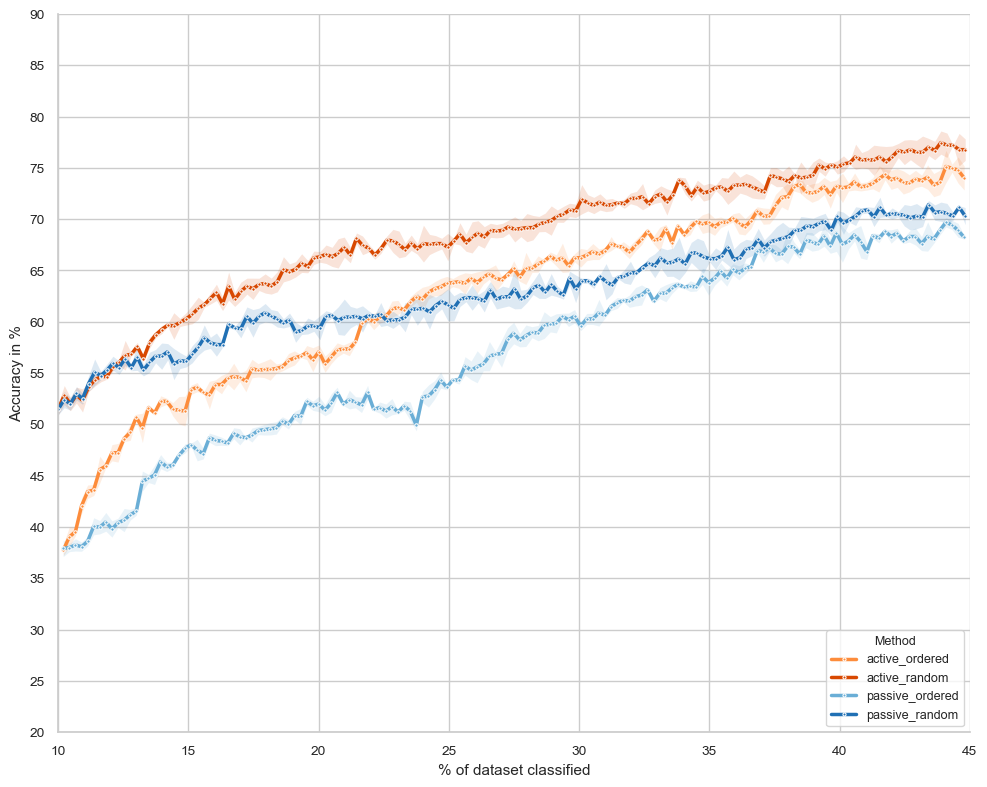

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='% of dataset classified', ylabel='Accuracy in %'>)

In [11]:
df = pd.read_csv('results/al_results_hash65536_lr0.0014005_bs2048_ep16_k6_topk3_comm3_passcomm3_budget900_seed42_20250908_211459.csv')
# tilføj kolonne med classified i det loop
passive = ['passive_random','passive_ordered']

plot_acc_pct(df,y_min=0.2,y_max=.9,use_top_k=False,x_range=(0.1,0.45),methods=None)

# y=0,x=0, 